In [1]:
import os
import glob

base_dir = '/content/drive/MyDrive/UIT/mlop/face_mask'
# Tìm tất cả file .png trong thư mục images và các thư mục con
image_paths = glob.glob(os.path.join(base_dir, 'images', '**', '*.png'), recursive=True)

total_images = len(image_paths)
print(f"Tổng số ảnh có trong thư mục '{base_dir}': {total_images} ảnh")

Tổng số ảnh có trong thư mục '/content/drive/MyDrive/UIT/mlop/face_mask': 853 ảnh


In [2]:
splits = ['train', 'val', 'test']

for split in splits:
    split_dir = os.path.join(base_dir, 'images', split)
    if os.path.exists(split_dir):
        # Đếm file .png trực tiếp trong từng thư mục con
        count = len(glob.glob(os.path.join(split_dir, '*.png')))
        print(f"Số lượng ảnh trong tập {split.upper()}: {count} ảnh")
    else:
        print(f"⚠️ Cảnh báo: Không tìm thấy thư mục {split_dir}")

Số lượng ảnh trong tập TRAIN: 597 ảnh
Số lượng ảnh trong tập VAL: 170 ảnh
Số lượng ảnh trong tập TEST: 86 ảnh


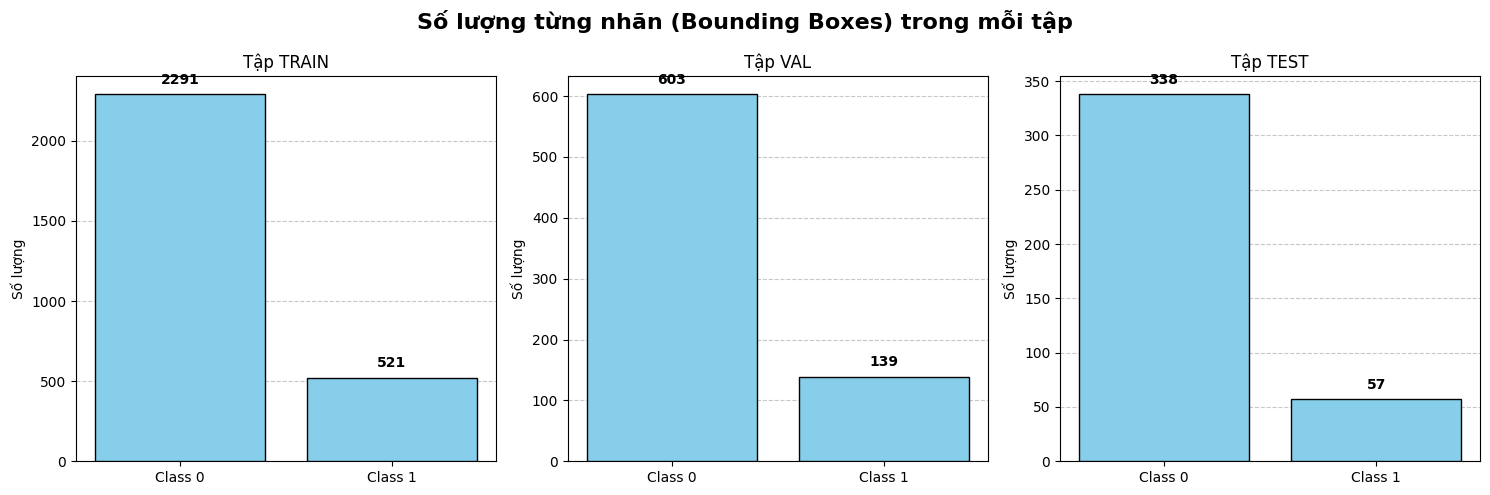

In [3]:
import matplotlib.pyplot as plt
from collections import Counter

splits = ['train', 'val', 'test']
split_class_counts = {}

# Đọc các file txt và đếm nhãn
for split in splits:
    label_dir = os.path.join(base_dir, 'labels', split)
    counts = Counter()
    if os.path.exists(label_dir):
        txt_files = glob.glob(os.path.join(label_dir, '*.txt'))
        for txt_file in txt_files:
            with open(txt_file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        # Trong format YOLO, class_id luôn nằm ở cột đầu tiên
                        class_id = int(parts[0])
                        counts[class_id] += 1
    split_class_counts[split] = counts

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Số lượng từng nhãn (Bounding Boxes) trong mỗi tập', fontsize=16, fontweight='bold')

for i, split in enumerate(splits):
    counts = split_class_counts[split]
    if counts:
        classes = sorted(list(counts.keys()))
        values = [counts[c] for c in classes]
        labels = [f"Class {c}" for c in classes]

        # Vẽ cột màu xanh da trời (skyblue)
        axes[i].bar(labels, values, color='skyblue', edgecolor='black', zorder=3)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

        # Thêm số liệu trực tiếp trên đỉnh cột
        for j, v in enumerate(values):
            axes[i].text(j, v + max(values)*0.02, str(v), ha='center', va='bottom', fontweight='bold')

    axes[i].set_title(f'Tập {split.upper()}')
    axes[i].set_ylabel('Số lượng')

plt.tight_layout()
plt.show()

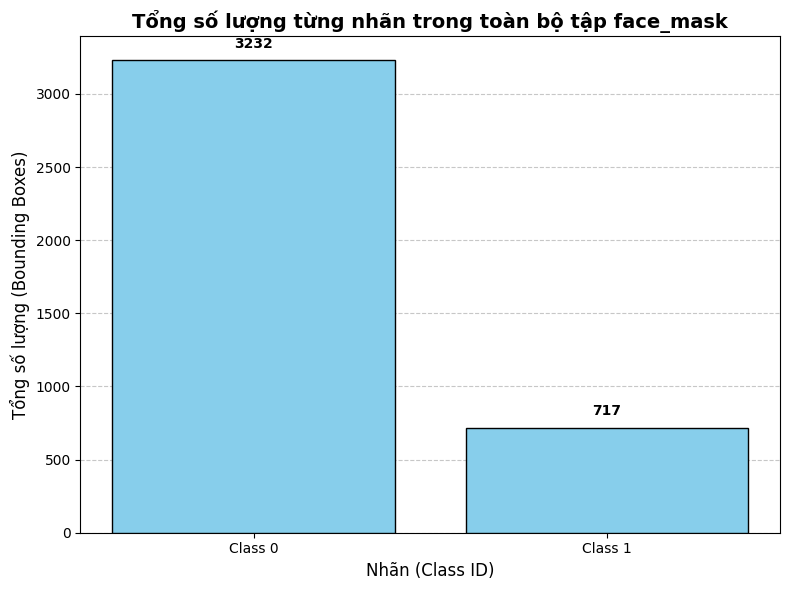

In [4]:
# Gộp data từ biến split_class_counts ở Cell 3
total_counts = Counter()
for split_counts in split_class_counts.values():
    total_counts.update(split_counts)

if total_counts:
    classes = sorted(list(total_counts.keys()))
    values = [total_counts[c] for c in classes]
    labels = [f"Class {c}" for c in classes]

    plt.figure(figsize=(8, 6))

    # Vẽ cột màu xanh da trời
    bars = plt.bar(labels, values, color='skyblue', edgecolor='black', zorder=3)

    plt.title('Tổng số lượng từng nhãn trong toàn bộ tập face_mask', fontsize=14, fontweight='bold')
    plt.xlabel('Nhãn (Class ID)', fontsize=12)
    plt.ylabel('Tổng số lượng (Bounding Boxes)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

    # Thêm số liệu trực tiếp trên đỉnh cột
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + max(values)*0.02, int(yval), ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy nhãn nào trong toàn bộ dataset.")